# 11. Multi-output 고도화 모델 + SHAP 설명 가능성

MobileNetV3 백본에 3개 출력 헤드를 붙인 **AdvancedDefectPredictor**를 구현합니다.

| 헤드 | 출력 | 역할 |
|------|------|---------|
| Head 1 | 9-class softmax | 불량 분류 |
| Head 2 | 4-class softmax | 심각도 예측 (Critical/High/Medium/None) |
| Head 3 | sigmoid (0~1) | 신뢰도 스코어 |

**Multi-Task Loss:** `L = 0.5·CE(defect) + 0.3·CE(severity) + 0.2·MSE(confidence)`

**산출물:** `src/model_explainer.py`, `models/advanced_defect_predictor.py`, SHAP/Grad-CAM 시각화

## 1. 환경 설정

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, json, pickle, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
import torchvision.transforms as T

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP 미설치 → pip install shap')

# ── 경로 설정 ──
ROOT          = Path(os.getcwd())
DATA_PATH     = ROOT / 'data' / 'raw' / 'LSWMD.pkl'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MAPS_PATH     = PROCESSED_DIR / 'all_maps_resized.npy'
SPLIT_PATH    = PROCESSED_DIR / 'split_indices.pkl'
CONFIGS_DIR   = ROOT / 'configs'
ANALYSIS_DIR  = ROOT / 'analysis'
CKPT_DIR      = ROOT / 'checkpoints'
MODELS_DIR    = ROOT / 'models'
SRC_DIR       = ROOT / 'src'

MODELS_DIR.mkdir(exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CLASS_NAMES    = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES    = len(CLASS_NAMES)
CLASS_TO_IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}

SEVERITY_NAMES = ['Critical', 'High', 'Medium', 'None']
NUM_SEV        = len(SEVERITY_NAMES)

# ── matplotlib 한글 폰트 설정 (Windows: Malgun Gothic) ──
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


SHAP: 0.52.0
Device: cuda
GPU: NVIDIA GeForce RTX 2060 SUPER


## 2. 데이터 로드 & 심각도/신뢰도 레이블 생성

In [3]:
# ── WM-811K 레이블 로드 ──
df = pd.read_pickle(DATA_PATH)

def extract_label(x):
    """failureType 컬럼은 numpy ndarray([[label]]) 형태로 저장됨"""
    if isinstance(x, (list, np.ndarray)):
        if len(x) == 0:
            return 'unknown'
        inner = x[0]
        if isinstance(inner, (list, np.ndarray)):
            return str(inner[0]) if len(inner) > 0 else 'unknown'
        return str(inner)
    return str(x)

df['failureType_clean'] = df['failureType'].apply(extract_label)
df_valid = df[df['failureType_clean'].isin(CLASS_NAMES)].reset_index(drop=True)

# ── defect_metadata.json에서 심각도 로드 ──
with open(CONFIGS_DIR / 'defect_metadata.json', 'r', encoding='utf-8') as f:
    defect_meta = json.load(f)

# severity_level → 정수 (Critical=0, High=1, Medium=2, None=3)
SEV_MAP = {'Critical': 0, 'High': 1, 'Medium': 2, 'Low': 2, 'None': 3}

# 신뢰도 타겟 (심각도 비례 0~1)
CONF_MAP = {'Critical': 1.0, 'High': 0.70, 'Medium': 0.40, 'Low': 0.40, 'None': 0.0}

CLASS_SEVERITY = {}
CLASS_CONFIDENCE = {}
for cls in CLASS_NAMES:
    sev_level = defect_meta[cls]['severity_level']
    CLASS_SEVERITY[cls]   = SEV_MAP[sev_level]
    CLASS_CONFIDENCE[cls] = CONF_MAP[sev_level]

print('클래스별 심각도/신뢰도 타겟:')
for cls in CLASS_NAMES:
    print(f'  {cls:<12}: severity={SEVERITY_NAMES[CLASS_SEVERITY[cls]]:<8} confidence={CLASS_CONFIDENCE[cls]:.2f}')

# ── 64x64 맵 로드 ──
all_maps = np.load(MAPS_PATH)  # (172950, 64, 64) uint8

with open(SPLIT_PATH, 'rb') as f:
    split_indices = pickle.load(f)

# split_indices 키 정규화 — train_idx/val_idx/test_idx 또는 train/val/test 양쪽 지원
split_indices['train'] = split_indices.get('train_idx', split_indices.get('train'))
split_indices['val']   = split_indices.get('val_idx',   split_indices.get('val'))
split_indices['test']  = split_indices.get('test_idx',  split_indices.get('test'))

labels_all = df_valid['failureType_clean'].values
print(f'\nall_maps shape: {all_maps.shape}')
print(f'train: {len(split_indices["train"]):,} | val: {len(split_indices["val"]):,} | test: {len(split_indices["test"]):,}')
print(f'df_valid: {len(df_valid):,}개 (기대값: 172,950)')


클래스별 심각도/신뢰도 타겟:
  none        : severity=None     confidence=0.00
  Center      : severity=Critical confidence=1.00
  Donut       : severity=High     confidence=0.70
  Edge-Loc    : severity=High     confidence=0.70
  Edge-Ring   : severity=High     confidence=0.70
  Loc         : severity=Medium   confidence=0.40
  Near-full   : severity=Critical confidence=1.00
  Random      : severity=Medium   confidence=0.40
  Scratch     : severity=Medium   confidence=0.40

all_maps shape: (172950, 64, 64)
train: 121,065 | val: 25,942 | test: 25,943
df_valid: 172,950개 (기대값: 172,950)


## 3. WaferMultiTaskDataset & DataLoader

In [4]:
class WaferMultiTaskDataset(Dataset):
    """3-output 레이블: (defect_class, severity, confidence)"""

    def __init__(self, maps, labels, indices, augment=False):
        self.maps   = maps[indices]   # (N, 64, 64)
        self.labels = labels[indices]
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wmap  = self.maps[idx].astype(np.float32) / 2.0  # [0,1]
        cls   = self.labels[idx]

        if self.augment:
            if np.random.rand() > 0.5:
                wmap = np.fliplr(wmap).copy()
            if np.random.rand() > 0.5:
                wmap = np.flipud(wmap).copy()
            k = np.random.randint(0, 4)
            wmap = np.rot90(wmap, k).copy()

        img      = torch.tensor(wmap, dtype=torch.float32).unsqueeze(0)  # (1,64,64)
        defect   = CLASS_TO_IDX[cls]
        severity = CLASS_SEVERITY[cls]
        conf     = CLASS_CONFIDENCE[cls]
        return img, defect, severity, conf


BATCH_SIZE = 64

train_ds = WaferMultiTaskDataset(all_maps, labels_all, split_indices['train'], augment=True)
val_ds   = WaferMultiTaskDataset(all_maps, labels_all, split_indices['val'],   augment=False)
test_ds  = WaferMultiTaskDataset(all_maps, labels_all, split_indices['test'],  augment=False)

# 클래스 가중치 (불균형 처리)
train_labels_int = [CLASS_TO_IDX[labels_all[i]] for i in split_indices['train']]
class_counts = np.bincount(train_labels_int, minlength=NUM_CLASSES)
class_weights = torch.tensor(1.0 / (class_counts + 1), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
print(f'배치당 샘플: {BATCH_SIZE}, train iter: {len(train_loader)}')

Train: 121,065 | Val: 25,942 | Test: 25,943
배치당 샘플: 64, train iter: 1892


## 4. AdvancedDefectPredictor 모델 설계

In [5]:
class AdvancedDefectPredictor(nn.Module):
    """
    MobileNetV3 Small 백본 + 3-헤드 Multi-Task 출력
    Head1: 불량 분류 (9 classes)
    Head2: 심각도 분류 (4 classes)
    Head3: 신뢰도 스코어 (0~1, Sigmoid)
    """

    BACKBONE_DIM = 576  # MobileNetV3 Small features[-1] 채널 수
    SHARED_DIM   = 256

    def __init__(self, num_defect_classes=9, num_severity_classes=4, pretrained=True):
        super().__init__()

        # ── 백본 로드 ──
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = mobilenet_v3_small(weights=weights)

        # 3채널 → 1채널 적응 (pretrained 가중치 평균)
        old_conv = base.features[0][0]
        new_conv = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False)
        if pretrained:
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        base.features[0][0] = new_conv

        self.backbone = base.features  # (B,1,64,64) → (B,576,2,2)
        self.gap = nn.AdaptiveAvgPool2d(1)  # → (B,576,1,1)

        # ── Shared Representation ──
        self.shared = nn.Sequential(
            nn.Linear(self.BACKBONE_DIM, self.SHARED_DIM),
            nn.Hardswish(),
            nn.Dropout(0.3),
        )

        # ── Head 1: 불량 분류 ──
        self.defect_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_defect_classes),
        )

        # ── Head 2: 심각도 분류 ──
        self.severity_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_severity_classes),
        )

        # ── Head 3: 신뢰도 ──
        self.confidence_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat   = self.backbone(x)              # (B, 576, 2, 2)
        feat   = self.gap(feat).flatten(1)     # (B, 576)
        shared = self.shared(feat)             # (B, 256)
        return {
            'defect':     self.defect_head(shared),     # (B, 9)
            'severity':   self.severity_head(shared),   # (B, 4)
            'confidence': self.confidence_head(shared), # (B, 1)
        }

    def get_features(self, x):
        """공유 표현 벡터 반환 (SHAP 분석용)"""
        feat = self.backbone(x)
        return self.shared(self.gap(feat).flatten(1))


model = AdvancedDefectPredictor(pretrained=True).to(DEVICE)

# Step 5 체크포인트에서 백본 가중치 로드 시도
step5_ckpts = sorted(CKPT_DIR.glob('MobileNetV3_*.pth'))
if step5_ckpts:
    ckpt_path = step5_ckpts[-1]  # 가장 최신
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state = ckpt.get('model_state_dict', ckpt)
    backbone_state = {k.replace('features.', ''): v
                      for k, v in state.items() if k.startswith('features.')}
    missing, unexpected = model.backbone.load_state_dict(backbone_state, strict=False)
    print(f'Step5 백본 로드: {ckpt_path.name}')
    print(f'  missing={len(missing)}, unexpected={len(unexpected)}')
else:
    print('Step5 체크포인트 없음 → ImageNet pretrained 사용')

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'전체 파라미터: {total_params:,} | 학습 가능: {trainable:,}')

Step5 백본 로드: MobileNetV3_15_0.5736.pth
  missing=206, unexpected=0
전체 파라미터: 1,133,454 | 학습 가능: 1,133,454


## 5. Multi-Task Loss 함수

In [6]:
class MultiTaskLoss(nn.Module):
    """
    Total Loss = α·CE(defect) + β·CE(severity) + γ·MSE(confidence)
    α=0.5, β=0.3, γ=0.2
    """

    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.ce_defect   = nn.CrossEntropyLoss(weight=class_weights)
        self.ce_severity = nn.CrossEntropyLoss()
        self.mse_conf    = nn.MSELoss()

    def forward(self, outputs, targets):
        l_defect   = self.ce_defect(outputs['defect'], targets['defect'])
        l_severity = self.ce_severity(outputs['severity'], targets['severity'])
        l_conf     = self.mse_conf(outputs['confidence'], targets['confidence'].unsqueeze(1))

        total = self.alpha * l_defect + self.beta * l_severity + self.gamma * l_conf
        return total, {'defect': l_defect.item(),
                       'severity': l_severity.item(),
                       'confidence': l_conf.item()}


criterion = MultiTaskLoss(alpha=0.5, beta=0.3, gamma=0.2, class_weights=class_weights)

# 학습률: 백본은 작게, 헤드는 크게
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 5e-5},
    {'params': list(model.shared.parameters()) +
               list(model.defect_head.parameters()) +
               list(model.severity_head.parameters()) +
               list(model.confidence_head.parameters()), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print('MultiTaskLoss 초기화 완료')
print(f'  α(defect)={criterion.alpha}, β(severity)={criterion.beta}, γ(conf)={criterion.gamma}')

MultiTaskLoss 초기화 완료
  α(defect)=0.5, β(severity)=0.3, γ(conf)=0.2


## 6. 학습 루프

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    sub_losses = {'defect': 0.0, 'severity': 0.0, 'confidence': 0.0}
    all_defect_preds, all_defect_true = [], []

    for imgs, defect_lbl, sev_lbl, conf_tgt in loader:
        imgs      = imgs.to(device)
        targets   = {
            'defect':     defect_lbl.to(device),
            'severity':   sev_lbl.to(device),
            'confidence': conf_tgt.float().to(device),
        }
        optimizer.zero_grad()
        outputs = model(imgs)
        loss, sub = criterion(outputs, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        for k in sub_losses:
            sub_losses[k] += sub[k]
        all_defect_preds.extend(outputs['defect'].argmax(1).cpu().numpy())
        all_defect_true.extend(defect_lbl.numpy())

    n = len(loader)
    f1 = f1_score(all_defect_true, all_defect_preds, average='macro', zero_division=0)
    return total_loss / n, {k: v / n for k, v in sub_losses.items()}, f1


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    sub_losses = {'defect': 0.0, 'severity': 0.0, 'confidence': 0.0}
    all_defect_preds, all_defect_true = [], []
    all_sev_preds, all_sev_true = [], []

    for imgs, defect_lbl, sev_lbl, conf_tgt in loader:
        imgs    = imgs.to(device)
        targets = {
            'defect':     defect_lbl.to(device),
            'severity':   sev_lbl.to(device),
            'confidence': conf_tgt.float().to(device),
        }
        outputs = model(imgs)
        loss, sub = criterion(outputs, targets)

        total_loss += loss.item()
        for k in sub_losses:
            sub_losses[k] += sub[k]
        all_defect_preds.extend(outputs['defect'].argmax(1).cpu().numpy())
        all_defect_true.extend(defect_lbl.numpy())
        all_sev_preds.extend(outputs['severity'].argmax(1).cpu().numpy())
        all_sev_true.extend(sev_lbl.numpy())

    n = len(loader)
    defect_f1  = f1_score(all_defect_true, all_defect_preds, average='macro', zero_division=0)
    severity_f1= f1_score(all_sev_true, all_sev_preds, average='macro', zero_division=0)
    return (total_loss / n,
            {k: v / n for k, v in sub_losses.items()},
            defect_f1, severity_f1,
            all_defect_preds, all_defect_true)

print('학습 루프 함수 정의 완료')

학습 루프 함수 정의 완료


## 7. 모델 학습 (30 epochs, EarlyStopping patience=7)

In [8]:
EPOCHS   = 30
PATIENCE = 7

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [],
           'val_sev_f1': [], 'sub_train': [], 'sub_val': []}

best_val_f1  = 0.0
best_state   = None
patience_cnt = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_sub, tr_f1 = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_sub, vl_f1, vl_sev_f1, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_sev_f1'].append(vl_sev_f1)
    history['sub_train'].append(tr_sub)
    history['sub_val'].append(vl_sub)

    print(f'Epoch {epoch:02d}/{EPOCHS} '
          f'| tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} '
          f'| vl_loss={vl_loss:.4f} vl_f1={vl_f1:.4f} sev_f1={vl_sev_f1:.4f}')

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_state  = copy.deepcopy(model.state_dict())
        patience_cnt = 0
        ckpt_name = f'AdvancedDefectPredictor_best_{best_val_f1:.4f}.pth'
        torch.save({'model_state_dict': best_state,
                    'epoch': epoch,
                    'val_f1': best_val_f1,
                    'class_names': CLASS_NAMES,
                    'severity_names': SEVERITY_NAMES},
                   CKPT_DIR / ckpt_name)
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarlyStopping: {PATIENCE}에폭 개선 없음 → 학습 종료')
            break

# 최적 가중치 복원
model.load_state_dict(best_state)
print(f'\n학습 완료 | Best Val F1(defect): {best_val_f1:.4f}')

Epoch 01/30 | tr_loss=0.5985 tr_f1=0.4819 | vl_loss=0.4297 vl_f1=0.5890 sev_f1=0.7664
Epoch 02/30 | tr_loss=0.4159 tr_f1=0.6370 | vl_loss=0.3971 vl_f1=0.6886 sev_f1=0.8136
Epoch 03/30 | tr_loss=0.3620 tr_f1=0.6758 | vl_loss=0.3676 vl_f1=0.6958 sev_f1=0.8357
Epoch 04/30 | tr_loss=0.3410 tr_f1=0.7026 | vl_loss=0.3195 vl_f1=0.7491 sev_f1=0.8517
Epoch 05/30 | tr_loss=0.3211 tr_f1=0.7235 | vl_loss=0.3064 vl_f1=0.7508 sev_f1=0.8577
Epoch 06/30 | tr_loss=0.2930 tr_f1=0.7470 | vl_loss=0.2758 vl_f1=0.7398 sev_f1=0.8655
Epoch 07/30 | tr_loss=0.2870 tr_f1=0.7479 | vl_loss=0.2979 vl_f1=0.7461 sev_f1=0.8611
Epoch 08/30 | tr_loss=0.2694 tr_f1=0.7612 | vl_loss=0.2651 vl_f1=0.7650 sev_f1=0.8800
Epoch 09/30 | tr_loss=0.2537 tr_f1=0.7679 | vl_loss=0.2763 vl_f1=0.7845 sev_f1=0.8741
Epoch 10/30 | tr_loss=0.2580 tr_f1=0.7794 | vl_loss=0.2574 vl_f1=0.7600 sev_f1=0.8876
Epoch 11/30 | tr_loss=0.2388 tr_f1=0.7857 | vl_loss=0.2712 vl_f1=0.7901 sev_f1=0.8912
Epoch 12/30 | tr_loss=0.2299 tr_f1=0.7919 | vl_loss=0.

## 8. 학습 곡선 & 헤드별 성능 시각화

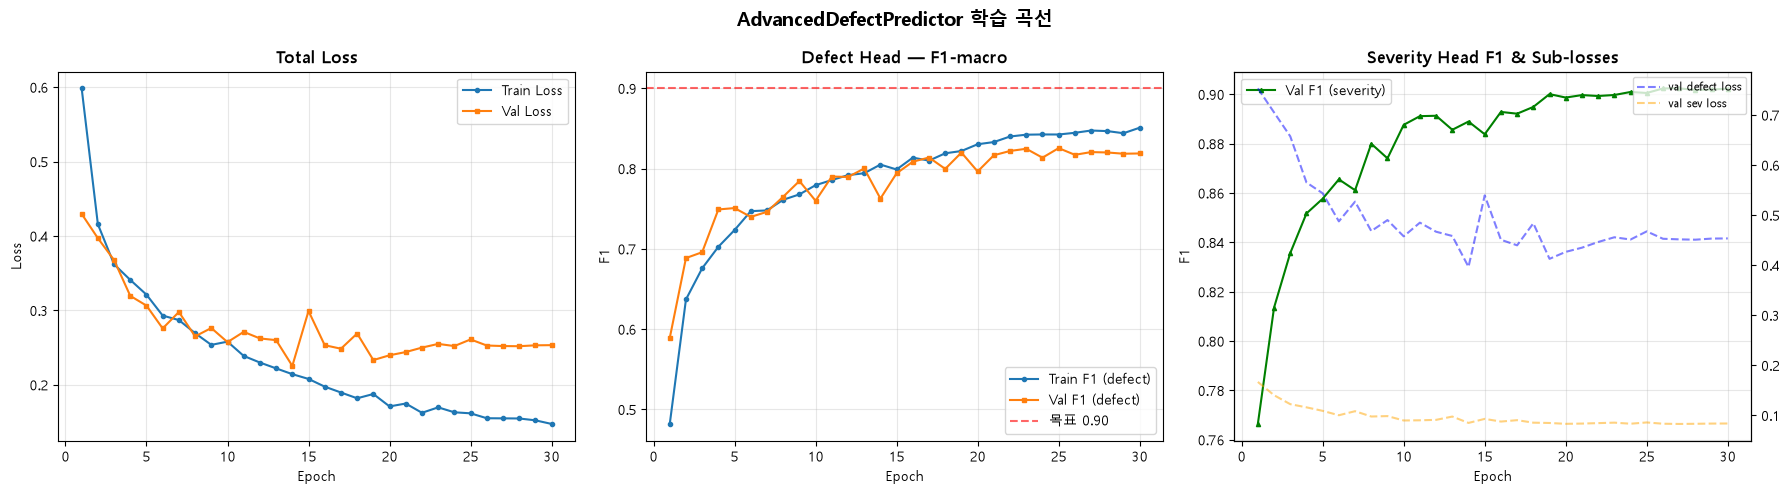

저장: analysis/advanced_model_training_curves.png


In [9]:
epochs_ran = len(history['train_loss'])
x_axis = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AdvancedDefectPredictor 학습 곡선', fontsize=14, fontweight='bold')

# 손실
axes[0].plot(x_axis, history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(x_axis, history['val_loss'],   label='Val Loss',   marker='s', markersize=3)
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Defect F1
axes[1].plot(x_axis, history['train_f1'], label='Train F1 (defect)', marker='o', markersize=3)
axes[1].plot(x_axis, history['val_f1'],   label='Val F1 (defect)',   marker='s', markersize=3)
axes[1].set_title('Defect Head — F1-macro', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].axhline(0.90, color='red', linestyle='--', label='목표 0.90', alpha=0.6)
axes[1].legend(); axes[1].grid(alpha=0.3)

# Severity F1
axes[2].plot(x_axis, history['val_sev_f1'], label='Val F1 (severity)', color='green',
             marker='^', markersize=3)
sub_defect_loss = [s['defect']   for s in history['sub_val']]
sub_sev_loss    = [s['severity'] for s in history['sub_val']]
ax2 = axes[2].twinx()
ax2.plot(x_axis, sub_defect_loss, label='val defect loss', color='blue',   linestyle='--', alpha=0.5)
ax2.plot(x_axis, sub_sev_loss,    label='val sev loss',    color='orange', linestyle='--', alpha=0.5)
axes[2].set_title('Severity Head F1 & Sub-losses', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].legend(loc='upper left'); ax2.legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'advanced_model_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/advanced_model_training_curves.png')

## 9. 테스트 세트 평가

=== 테스트 세트 결과 ===
Defect Head  F1-macro : 0.8130
Severity Head F1-macro: 0.8982

[Defect Head 분류 리포트]
              precision    recall  f1-score   support

        none       0.99      0.97      0.98     22115
      Center       0.80      0.94      0.87       644
       Donut       0.84      0.84      0.84        83
    Edge-Loc       0.66      0.87      0.75       779
   Edge-Ring       0.95      0.98      0.96      1452
         Loc       0.62      0.79      0.69       539
   Near-full       0.80      0.73      0.76        22
      Random       0.82      0.86      0.84       130
     Scratch       0.55      0.72      0.62       179

    accuracy                           0.96     25943
   macro avg       0.78      0.86      0.81     25943
weighted avg       0.96      0.96      0.96     25943



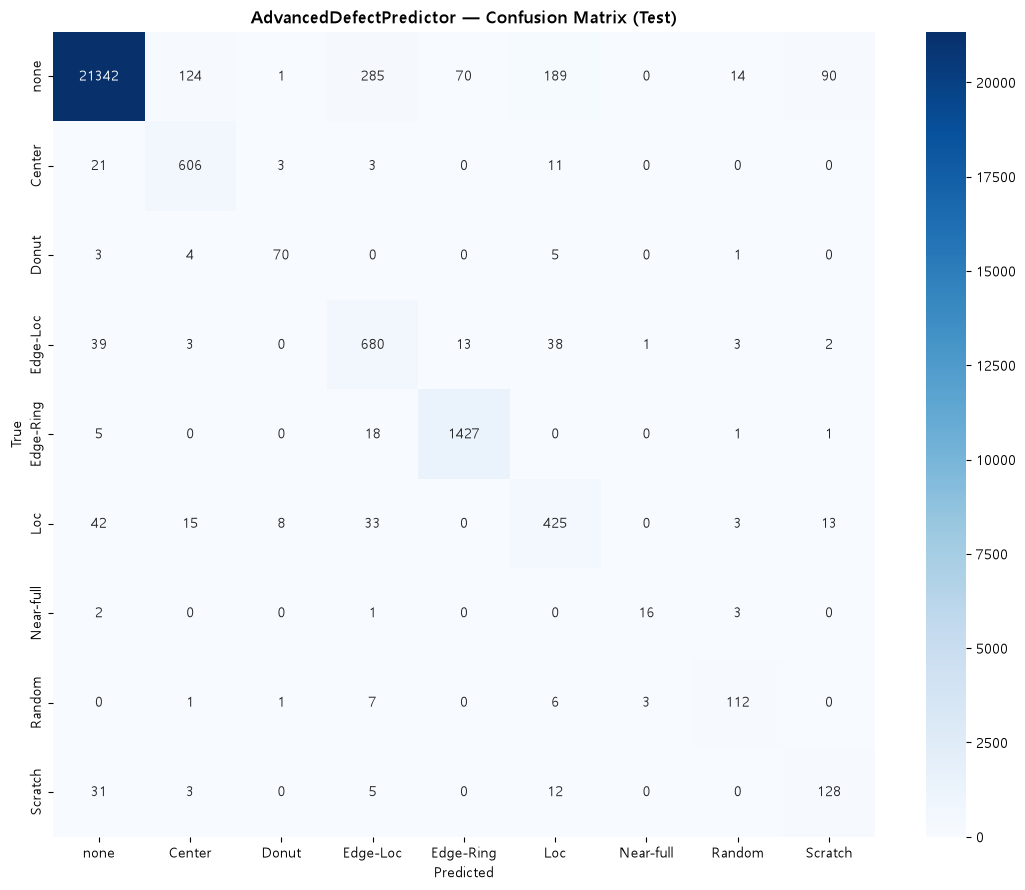

저장: analysis/advanced_model_confusion_matrix.png


In [10]:
_, _, test_defect_f1, test_sev_f1, preds, trues = eval_epoch(
    model, test_loader, criterion, DEVICE
)
print(f'=== 테스트 세트 결과 ===')
print(f'Defect Head  F1-macro : {test_defect_f1:.4f}')
print(f'Severity Head F1-macro: {test_sev_f1:.4f}')

print('\n[Defect Head 분류 리포트]')
print(classification_report(trues, preds, target_names=CLASS_NAMES, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(trues, preds)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('AdvancedDefectPredictor — Confusion Matrix (Test)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'advanced_model_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/advanced_model_confusion_matrix.png')

## 10. SHAP DeepExplainer — 픽셀 기여도 분석

In [11]:
# RuntimeError 원인 (두 가지 동시 작용):
# (1) 이전 SHAP GradientExplainer 초기화 시 register_backward_hook() 등록 후 미정리
#     -> BackwardHookFunctionBackward 노드가 computation graph에 잔존
# (2) DefectHeadWrapper.forward()의 flatten(1)이 view 반환
#     -> BackwardHookFunctionBackward 출력 view + 이후 연산 충돌 -> RuntimeError
#
# 해결 3단계:
# (1) clear_all_hooks(): SHAP 잔여 hook 완전 제거
# (2) disable_inplace(): MobileNetV3 내 25개 inplace 연산 비활성화
# (3) IGWrapper: flatten(1).clone()으로 view -> 독립 텐서 변환

def clear_all_hooks(model):
    """SHAP/MLflow 등이 등록한 backward/forward hook 전체 제거"""
    for m in model.modules():
        m._backward_hooks.clear()
        m._forward_hooks.clear()
        m._forward_pre_hooks.clear()
        if hasattr(m, '_backward_pre_hooks'):
            m._backward_pre_hooks.clear()

def disable_inplace(model):
    """MobileNetV3 내 25개 inplace 연산 (Hardswish/ReLU/Dropout) 비활성화"""
    for m in model.modules():
        if hasattr(m, 'inplace') and m.inplace:
            m.inplace = False

class IGWrapper(nn.Module):
    """Integrated Gradients 전용 래퍼: flatten(1).clone()으로 view 관계 차단"""
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        feat = self.model.backbone(x)
        feat = self.model.gap(feat).flatten(1).clone()  # clone()이 핵심
        shared = self.model.shared(feat)
        return self.model.defect_head(shared)

def compute_integrated_gradients(wrapper, bg_samples, X_inputs, n_classes=9, n_steps=30):
    """
    Integrated Gradients (SHAP GradientExplainer 수학적 동등)
    baseline -> input 직선 경로의 gradient 적분 x delta
    반환: list[n_classes] of ndarray (N, 1, 64, 64)
    """
    wrapper.eval()
    baseline = bg_samples.mean(dim=0, keepdim=True).detach()
    results = []

    for cls_idx in range(n_classes):
        class_attrs = []
        for i in range(len(X_inputs)):
            inp = X_inputs[i:i+1].detach()
            grads_sum = torch.zeros_like(inp)

            for alpha in np.linspace(0.0, 1.0, n_steps):
                x_step = (baseline + float(alpha) * (inp - baseline)).detach().clone()
                x_step.requires_grad_(True)
                out = wrapper(x_step)
                out[0, cls_idx].backward()
                grads_sum = grads_sum + x_step.grad.detach()

            ig = ((inp - baseline) * grads_sum / n_steps).numpy()
            class_attrs.append(ig[0])   # (1,64,64)

        results.append(np.array(class_attrs))   # (N,1,64,64)

    return results   # list[9] of (N,1,64,64)


# 실행
_orig_device = DEVICE
model_cpu = model.cpu().eval()
clear_all_hooks(model_cpu)    # (1) SHAP 잔여 hook 제거
disable_inplace(model_cpu)    # (2) inplace 25개 비활성화
wrapper_ig = IGWrapper(model_cpu)   # (3) clone() 래퍼 사용

# 배경: none 클래스 20개
none_indices = [i for i, c in enumerate(labels_all[split_indices['train']]) if c == 'none']
bg_idx       = np.random.choice(none_indices, min(20, len(none_indices)), replace=False)
bg_samples_cpu = torch.stack([train_ds[i][0] for i in bg_idx])   # (20,1,64,64)

# 테스트: 각 불량 클래스에서 최대 2개
test_samples, test_true_cls = [], []
test_labels = labels_all[split_indices['test']]
for cls in CLASS_NAMES[1:]:
    cls_idx = [i for i, c in enumerate(test_labels) if c == cls]
    if cls_idx:
        chosen = np.random.choice(cls_idx, min(2, len(cls_idx)), replace=False)
        for i in chosen:
            test_samples.append(test_ds[i][0].cpu())
            test_true_cls.append(cls)

X_test_shap = torch.stack(test_samples)   # (N,1,64,64)

n_test = len(X_test_shap)
print(f'배경 샘플: {len(bg_samples_cpu)}, 테스트 샘플: {n_test}')
print(f'Integrated Gradients 계산 중 ({NUM_CLASSES} 클래스 x {n_test} 샘플 x 30 스텝)...')

shap_values = compute_integrated_gradients(
    wrapper_ig, bg_samples_cpu, X_test_shap, n_classes=NUM_CLASSES, n_steps=30
)

# GPU 복귀
model.to(_orig_device)
X_test_shap = X_test_shap.to(_orig_device)

print(f'완료: list[{len(shap_values)}] shape={shap_values[0].shape}')
SHAP_AVAILABLE = True   # 후속 시각화 셀의 SHAP_AVAILABLE 분기 통과


배경 샘플: 20, 테스트 샘플: 16
Integrated Gradients 계산 중 (9 클래스 x 16 샘플 x 30 스텝)...
완료: list[9] shape=(16, 1, 64, 64)


## 11. SHAP 픽셀 중요도 시각화

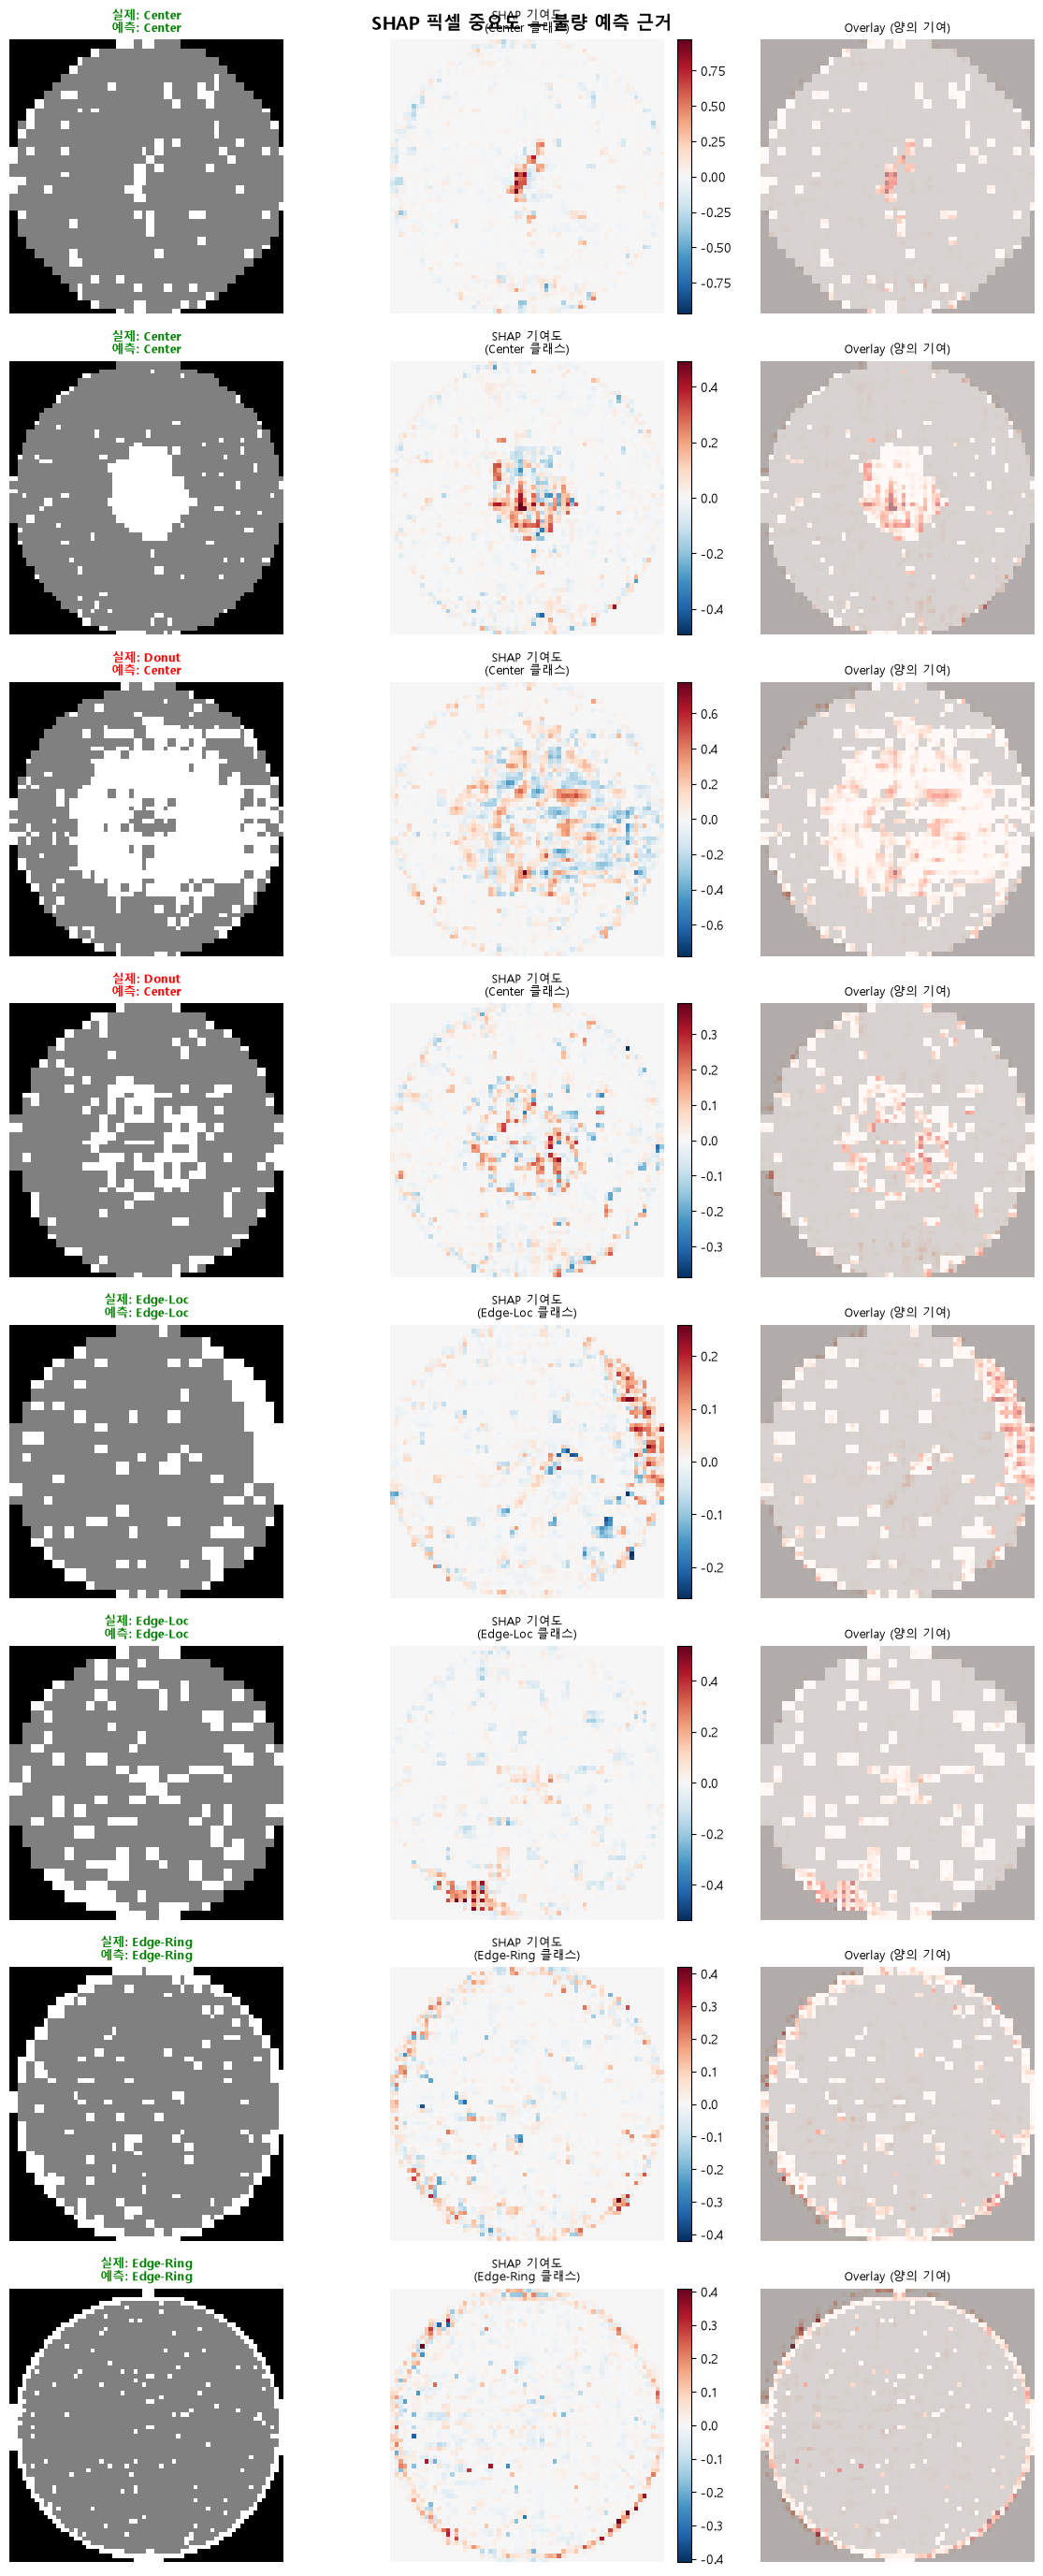

저장: analysis/shap_pixel_importance.png


In [16]:
if not SHAP_AVAILABLE:
    print('SHAP 미설치 → 건너뜀')
else:
    # 예측 클래스별 SHAP 히트맵
    with torch.no_grad():
        logits = wrapper_ig(X_test_shap)  # model.to(DEVICE)로 GPU 복귀했으므로 그대로 전달
        pred_classes = logits.argmax(1).cpu().numpy()

    n_show = min(len(test_true_cls), 8)
    fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('SHAP 픽셀 중요도 — 불량 예측 근거', fontsize=14, fontweight='bold')

    for i in range(n_show):
        img_np = X_test_shap[i, 0].cpu().numpy()  # (64,64)
        pred_cls_idx = pred_classes[i]
        shap_map = shap_values[pred_cls_idx][i, 0]  # (64,64) — 예측 클래스 기여도
        abs_sum  = np.array([sv[i, 0].sum() for sv in shap_values])  # 클래스별 총 기여도

        # 원본 웨이퍼 맵
        axes[i, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(f'실제: {test_true_cls[i]}\n예측: {CLASS_NAMES[pred_cls_idx]}',
                              fontsize=9, fontweight='bold',
                              color='green' if test_true_cls[i] == CLASS_NAMES[pred_cls_idx] else 'red')
        axes[i, 0].axis('off')

        # SHAP 히트맵 (예측 클래스)
        vmax = np.abs(shap_map).max() + 1e-8
        im = axes[i, 1].imshow(shap_map, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[i, 1].set_title(f'SHAP 기여도\n({CLASS_NAMES[pred_cls_idx]} 클래스)', fontsize=9)
        axes[i, 1].axis('off')
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

        # Overlay
        axes[i, 2].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.6)
        axes[i, 2].imshow(np.clip(shap_map, 0, None), cmap='Reds',
                          alpha=0.5, vmin=0, vmax=vmax)
        axes[i, 2].set_title('Overlay (양의 기여)', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / 'shap_pixel_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('저장: analysis/shap_pixel_importance.png')

## 12. SHAP Summary — 클래스별 평균 기여도

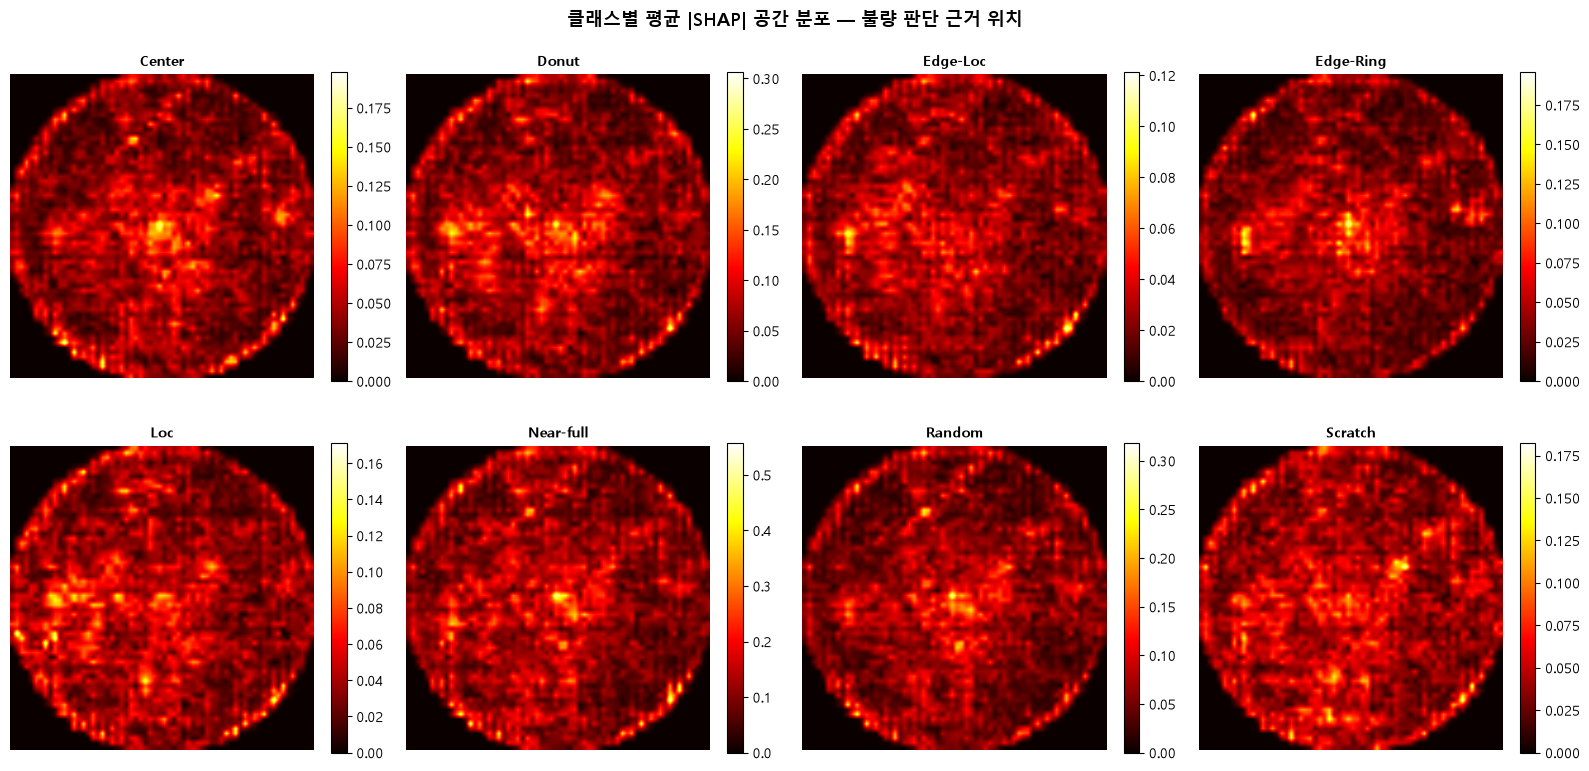

저장: analysis/shap_summary_per_class.png


In [17]:
if not SHAP_AVAILABLE:
    print('SHAP 미설치 → 건너뜀')
else:
    # 각 불량 클래스별 평균 |SHAP| 공간 맵
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes_flat = axes.flatten()
    fig.suptitle('클래스별 평균 |SHAP| 공간 분포 — 불량 판단 근거 위치',
                 fontsize=13, fontweight='bold')

    for j, cls_name in enumerate(CLASS_NAMES[1:]):  # none 제외
        ax = axes_flat[j]
        cls_idx = CLASS_TO_IDX[cls_name]
        sv_cls = shap_values[cls_idx]  # (N, 1, 64, 64)
        mean_abs_shap = np.abs(sv_cls[:, 0, :, :]).mean(axis=0)  # (64,64)
        im = ax.imshow(mean_abs_shap, cmap='hot', interpolation='bilinear')
        ax.set_title(f'{cls_name}', fontweight='bold', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / 'shap_summary_per_class.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('저장: analysis/shap_summary_per_class.png')

## 13. Grad-CAM 구현 & SHAP 비교

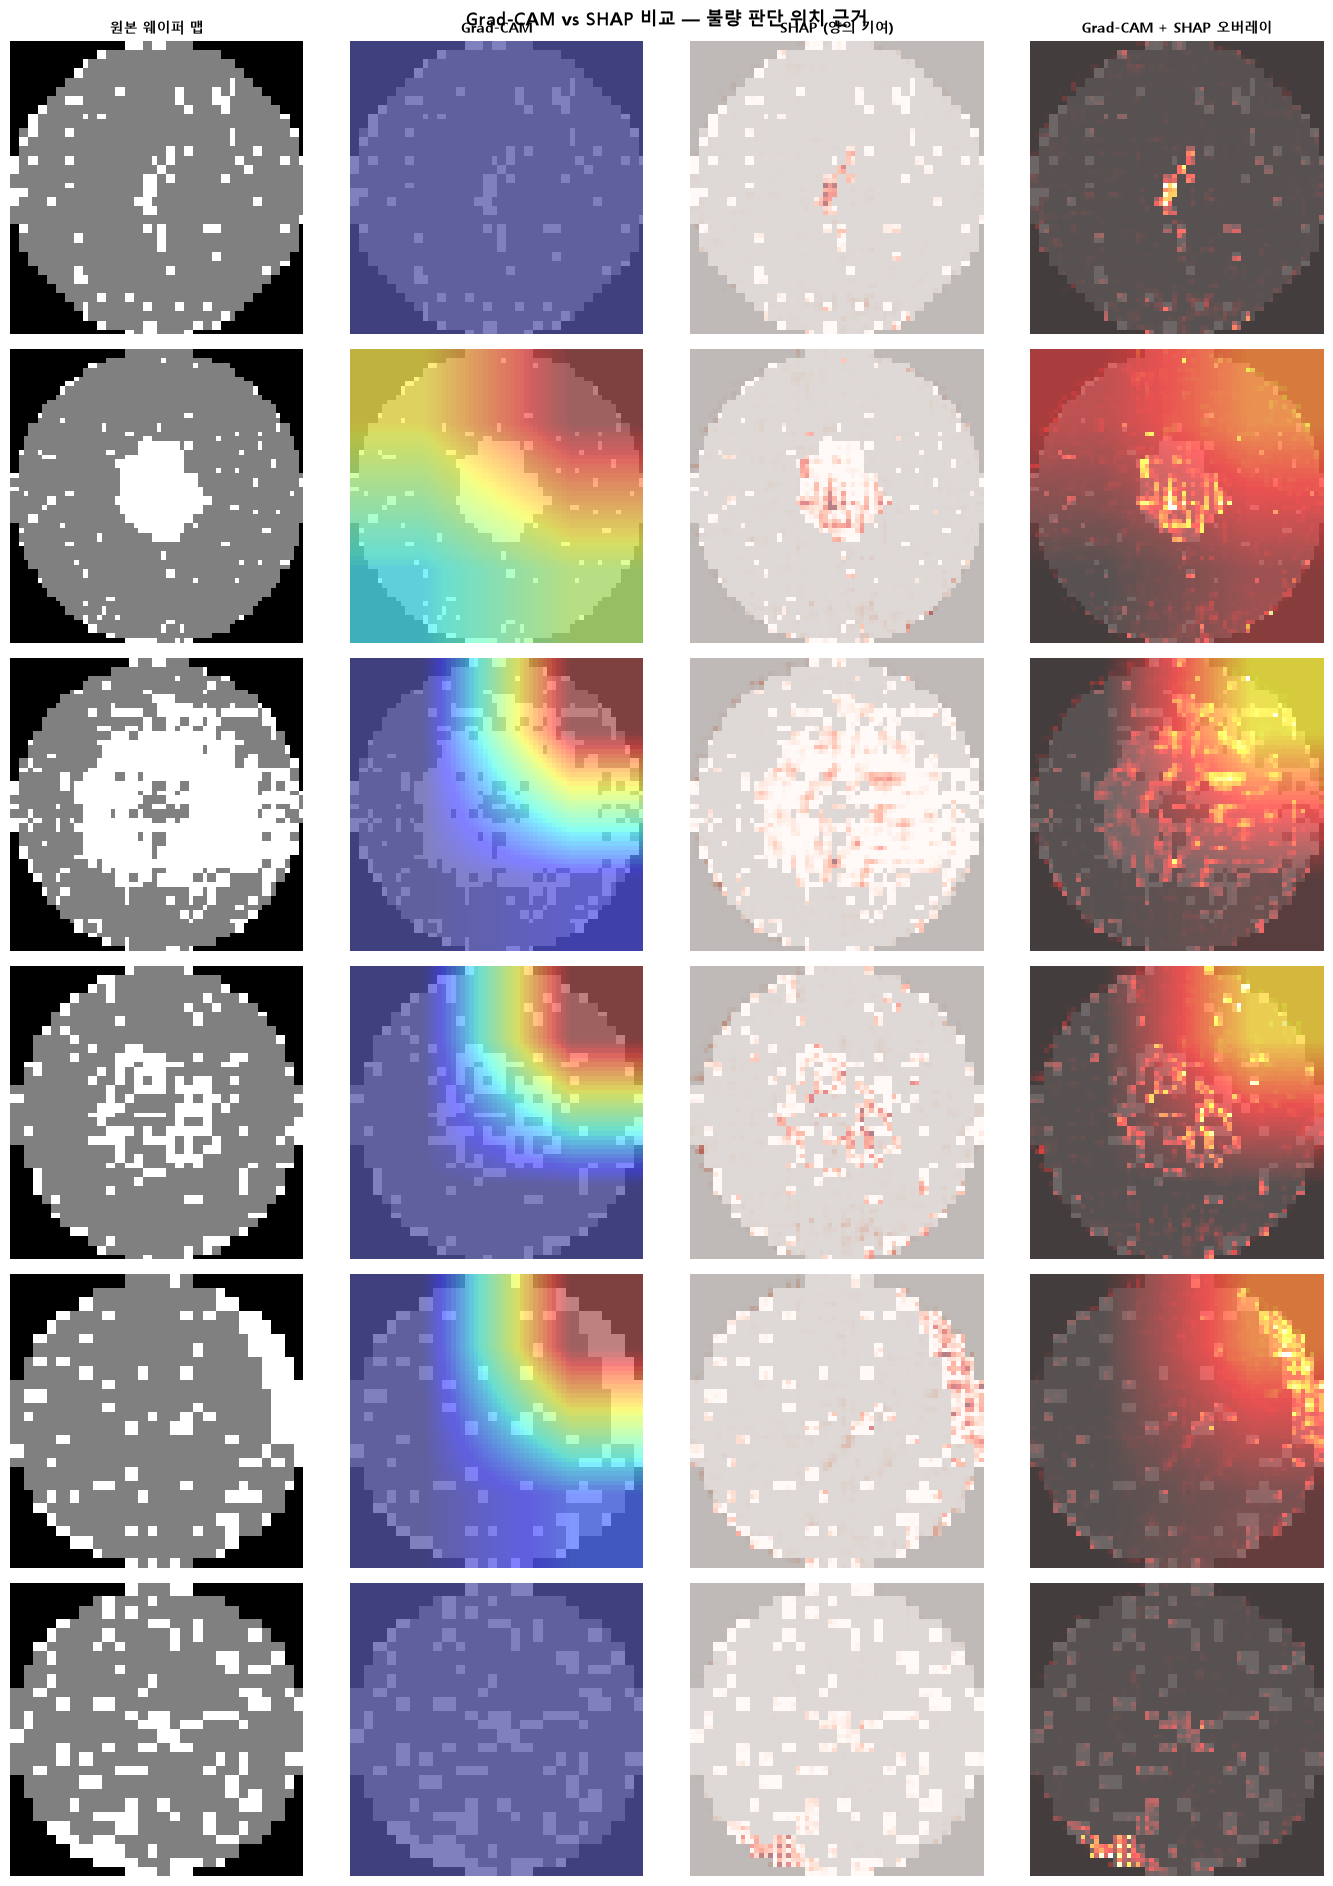

저장: analysis/shap_vs_gradcam.png


In [18]:
class GradCAM:
    """Grad-CAM — AdvancedDefectPredictor defect head 기준"""

    def __init__(self, model, target_layer):
        self.model  = model
        self.layer  = target_layer
        self._acts  = None
        self._grads = None
        self._fwd_hook = target_layer.register_forward_hook(self._save_act)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self._acts = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self._grads = grad_out[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        x = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
        out = self.model(x)['defect']                # (1, 9)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        weights = self._grads.mean(dim=(2, 3), keepdim=True)  # (1,C,1,1)
        cam = (weights * self._acts).sum(dim=1, keepdim=True)  # (1,1,H,W)
        cam = F.relu(cam).squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, class_idx

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# target layer: backbone의 마지막 conv block
target_layer = model.backbone[-1][0]
gradcam = GradCAM(model, target_layer)

# SHAP vs Grad-CAM 비교 (각 불량 클래스 대표 1개)
n_compare = min(len(test_true_cls), 6)
fig, axes = plt.subplots(n_compare, 4, figsize=(14, n_compare * 3.2))
if n_compare == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Grad-CAM vs SHAP 비교 — 불량 판단 위치 근거', fontsize=13, fontweight='bold')

col_titles = ['원본 웨이퍼 맵', 'Grad-CAM', 'SHAP (양의 기여)', 'Grad-CAM + SHAP 오버레이']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontweight='bold', fontsize=10)

for i in range(n_compare):
    img_tensor = X_test_shap[i]  # (1,64,64)
    img_np     = img_tensor[0].cpu().numpy()
    pred_idx   = pred_classes[i] if SHAP_AVAILABLE else CLASS_TO_IDX[test_true_cls[i]]

    # Grad-CAM
    cam_map, cam_cls = gradcam.generate(img_tensor, class_idx=pred_idx)
    import cv2
    cam_resized = cv2.resize(cam_map, (64, 64)) if cam_map.shape != (64, 64) else cam_map

    # 원본
    axes[i, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(f'{test_true_cls[i]}\n→{CLASS_NAMES[pred_idx]}',
                          fontsize=8, rotation=0, labelpad=55, va='center')
    axes[i, 0].axis('off')

    # Grad-CAM
    axes[i, 1].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    axes[i, 1].imshow(cam_resized, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[i, 1].axis('off')

    if SHAP_AVAILABLE:
        # SHAP
        sv = np.clip(shap_values[pred_idx][i, 0], 0, None)
        sv_norm = sv / (sv.max() + 1e-8)
        axes[i, 2].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.5)
        axes[i, 2].imshow(sv_norm, cmap='Reds', alpha=0.5)
        axes[i, 2].axis('off')

        # 오버레이 (평균)
        combined = (cam_resized + sv_norm) / 2
        axes[i, 3].imshow(img_np, cmap='gray', vmin=0, vmax=1, alpha=0.4)
        axes[i, 3].imshow(combined, cmap='hot', alpha=0.6)
        axes[i, 3].axis('off')
    else:
        axes[i, 2].axis('off')
        axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'shap_vs_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
gradcam.remove_hooks()
print('저장: analysis/shap_vs_gradcam.png')

## 14. 모델 클래스 파일 저장

In [19]:
model_code = '''
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights


class AdvancedDefectPredictor(nn.Module):
    """
    MobileNetV3 Small 백본 + 3-헤드 Multi-Task 출력
    Head1: 불량 분류 (num_defect_classes)
    Head2: 심각도 분류 (Critical/High/Medium/None = 4)
    Head3: 신뢰도 스코어 (0~1)
    """

    BACKBONE_DIM = 576
    SHARED_DIM   = 256

    def __init__(self, num_defect_classes=9, num_severity_classes=4, pretrained=True):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        base = mobilenet_v3_small(weights=weights)

        old_conv = base.features[0][0]
        new_conv = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False)
        if pretrained:
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        base.features[0][0] = new_conv

        self.backbone = base.features
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.shared = nn.Sequential(
            nn.Linear(self.BACKBONE_DIM, self.SHARED_DIM),
            nn.Hardswish(),
            nn.Dropout(0.3),
        )
        self.defect_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_defect_classes),
        )
        self.severity_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, num_severity_classes),
        )
        self.confidence_head = nn.Sequential(
            nn.Linear(self.SHARED_DIM, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        feat   = self.backbone(x)
        feat   = self.gap(feat).flatten(1)
        shared = self.shared(feat)
        return {
            'defect':     self.defect_head(shared),
            'severity':   self.severity_head(shared),
            'confidence': self.confidence_head(shared),
        }

    @classmethod
    def from_checkpoint(cls, ckpt_path, device='cpu', **kwargs):
        ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = cls(**kwargs)
        model.load_state_dict(ckpt['model_state_dict'])
        model.to(device).eval()
        return model
'''

model_path = MODELS_DIR / 'advanced_defect_predictor.py'
with open(model_path, 'w', encoding='utf-8') as f:
    f.write(model_code.strip())
print(f'저장: {model_path}')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\models\advanced_defect_predictor.py


## 15. ModelExplainer 클래스 저장

In [20]:
explainer_code = '''
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


class GradCAM:
    """AdvancedDefectPredictor defect head 기준 Grad-CAM"""

    def __init__(self, model, target_layer):
        self.model  = model
        self._acts  = None
        self._grads = None
        self._fwd   = target_layer.register_forward_hook(self._fwd_hook)
        self._bwd   = target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, m, inp, out): self._acts  = out.detach()
    def _bwd_hook(self, m, gi, go):  self._grads = go[0].detach()

    def generate(self, x, class_idx=None, device='cpu'):
        self.model.eval()
        x = x.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)['defect']
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()

        w   = self._grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self._acts).sum(1, keepdim=True)).squeeze().cpu().numpy()
        return cam / (cam.max() + 1e-8), class_idx

    def remove(self):
        self._fwd.remove(); self._bwd.remove()


class SHAPExplainer:
    """shap.DeepExplainer 래퍼 — defect head 기준 픽셀 기여도"""

    def __init__(self, model, background: torch.Tensor):
        import shap

        class _Wrapper(torch.nn.Module):
            def __init__(self, m): super().__init__(); self.m = m
            def forward(self, x): return self.m(x)[\'defect\']

        self.explainer = shap.DeepExplainer(_Wrapper(model), background)

    def explain(self, X: torch.Tensor):
        """Returns list[9] of (N,1,64,64) SHAP value arrays"""
        return self.explainer.shap_values(X)

    @staticmethod
    def plot(img_np, shap_map, class_name, save_path=None):
        """단일 샘플 SHAP 시각화"""
        fig, axes = plt.subplots(1, 3, figsize=(11, 4))
        axes[0].imshow(img_np, cmap="gray")
        axes[0].set_title("원본")
        vmax = np.abs(shap_map).max() + 1e-8
        axes[1].imshow(shap_map, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[1].set_title(f"SHAP ({class_name})")
        axes[2].imshow(img_np, cmap="gray", alpha=0.5)
        axes[2].imshow(np.clip(shap_map, 0, None), cmap="Reds", alpha=0.5)
        axes[2].set_title("Overlay")
        for ax in axes: ax.axis("off")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.show()
'''

exp_path = SRC_DIR / 'model_explainer.py'
with open(exp_path, 'w', encoding='utf-8') as f:
    f.write(explainer_code.strip())
print(f'저장: {exp_path}')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\src\model_explainer.py


## 16. 결과 JSON 저장 & 산출물 최종 확인

In [21]:
# ── 멀티태스크 결과 저장 ──
result_dict = {
    'model': 'AdvancedDefectPredictor (MobileNetV3 Small + 3 heads)',
    'best_val_defect_f1': round(best_val_f1, 4),
    'test_defect_f1':     round(test_defect_f1, 4),
    'test_severity_f1':   round(test_sev_f1, 4),
    'epochs_trained':     len(history['train_loss']),
    'loss_weights': {'alpha': 0.5, 'beta': 0.3, 'gamma': 0.2},
    'class_names': CLASS_NAMES,
    'severity_names': SEVERITY_NAMES,
    'shap_available': SHAP_AVAILABLE,
}

result_path = ANALYSIS_DIR / 'advanced_model_results.json'
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result_dict, f, ensure_ascii=False, indent=2)
print(f'저장: {result_path}')

# ── 산출물 목록 ──
outputs = [
    CKPT_DIR     / f'AdvancedDefectPredictor_best_{best_val_f1:.4f}.pth',
    MODELS_DIR   / 'advanced_defect_predictor.py',
    SRC_DIR      / 'model_explainer.py',
    ANALYSIS_DIR / 'advanced_model_training_curves.png',
    ANALYSIS_DIR / 'advanced_model_confusion_matrix.png',
    ANALYSIS_DIR / 'advanced_model_results.json',
    ANALYSIS_DIR / 'shap_vs_gradcam.png',
]
if SHAP_AVAILABLE:
    outputs += [
        ANALYSIS_DIR / 'shap_pixel_importance.png',
        ANALYSIS_DIR / 'shap_summary_per_class.png',
    ]

print('\n=== Step 11 산출물 목록 ===')
all_ok = True
for p in outputs:
    exists = p.exists()
    size   = f'{p.stat().st_size/1024:.1f}KB' if exists else '-'
    status = '✅' if exists else '❌'
    print(f'{status} {p.relative_to(ROOT)}  ({size})')
    if not exists: all_ok = False

print(f'\n결과: {"전체 완료" if all_ok else "일부 누락"}')
print(f'Best Val F1 (defect): {best_val_f1:.4f}')
print(f'Test F1 (defect): {test_defect_f1:.4f}  |  Test F1 (severity): {test_sev_f1:.4f}')
print('\nStep 11 완료 → Step 12 (공정 최적화 + ROI) 진행 가능')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\analysis\advanced_model_results.json

=== Step 11 산출물 목록 ===
✅ checkpoints\AdvancedDefectPredictor_best_0.8255.pth  (4561.4KB)
✅ models\advanced_defect_predictor.py  (2.3KB)
✅ src\model_explainer.py  (2.5KB)
✅ analysis\advanced_model_training_curves.png  (124.9KB)
✅ analysis\advanced_model_confusion_matrix.png  (68.3KB)
✅ analysis\advanced_model_results.json  (0.5KB)
✅ analysis\shap_vs_gradcam.png  (137.1KB)
✅ analysis\shap_pixel_importance.png  (302.9KB)
✅ analysis\shap_summary_per_class.png  (721.0KB)

결과: 전체 완료
Best Val F1 (defect): 0.8255
Test F1 (defect): 0.8130  |  Test F1 (severity): 0.8982

Step 11 완료 → Step 12 (공정 최적화 + ROI) 진행 가능
